In [1]:
# importing all the modules needed
!pip install biopython
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.cm as cm
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio.SeqUtils import ProtParamData
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, confusion_matrix
import seaborn as sns

# open the SVM matrix trained on all sets (.npz)
# buid df
data = np.load("training_features.npz", allow_pickle=True)

#picking columns and rows
X_full = data["X"]
y_full = data["y"]
feature_names = list(data["feature_names"])
seq_ids = data["seq_ids"]


df = pd.DataFrame(X_full, columns=feature_names)
df["label"] = y_full
df["seq_id"] = seq_ids

# opening saved best kernel, best c and gamma form training
cv_results = np.load("cv_results.npy", allow_pickle=True).item()

#importing the confusion matrix file and its funciton
from CM import plot_confusion_matrix_custom


---TRAIN FINAL MODEL ON FULL TRAINING DATA ---
Using best k from CV: 26
Final SVM params: C=1.0, gamma=scale

--- All Features Model ---
Accuracy: 0.974
F1 score: 0.884
MCC: 0.870


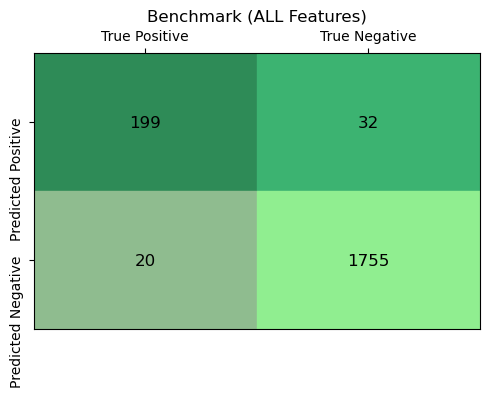

Saved confusion matrix to: CM_benchmark_ALL_features.png

--- Selected Features Model (Top k) ---
Accuracy: 0.974
F1 score: 0.882
MCC: 0.867


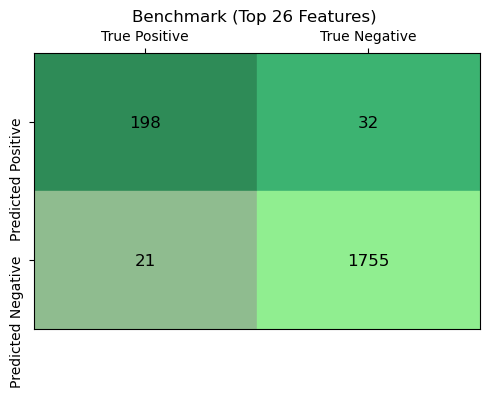

Saved confusion matrix to: CM_benchmark_selected.png


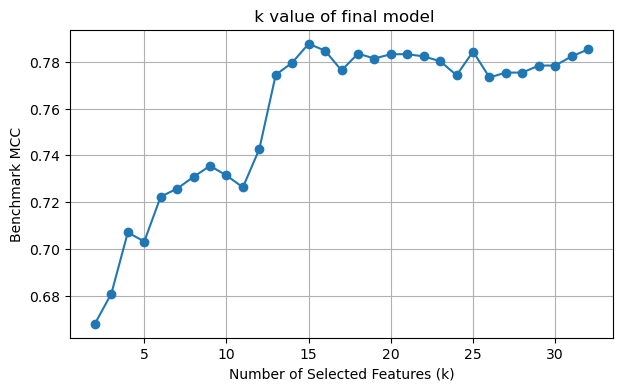


===== TOP-k SELECTED FEATURES =====

   feature  importance
    tm_max    0.200382
 hydro_max    0.175479
   tm_mean    0.097031
hydro_mean    0.094706
 hydro_std    0.082697
     sheet    0.033853
    charge    0.024542
      AA_L    0.024537
        pI    0.022239
 refr_mean    0.021460
  refr_max    0.018523
      AA_A    0.016789
      AA_C    0.016636
     helix    0.016030
      AA_I    0.014292
      turn    0.012865
      AA_V    0.010587
      AA_R    0.010293
      AA_G    0.009943
      AA_F    0.009280
      AA_P    0.009030
      AA_S    0.008847
      AA_T    0.008816
      AA_E    0.008567
      AA_K    0.008478
      AA_W    0.007629


In [2]:
# reading the benchmark file and creating a fasta dictionary
def read_fasta_to_dict():
    seqs = {}
    with open("benchmark.fasta", "r") as f:
        current_id = None
        current_seq = []
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if current_id is not None:
                    seqs[current_id] = "".join(current_seq)
                current_id = line[1:].split()[0]
                current_seq = []
            else:
                current_seq.append(line)
        if current_id is not None: 
            seqs[current_id] = "".join(current_seq) 
    return seqs
bench= read_fasta_to_dict()

# if positive 1 if negative 0
info= pd.read_csv("all.tsv", sep="\t")
label_mapping = dict(zip(info["UniprotAccession"], info["label"]))
bench_labels={}
for seq_id in bench.keys():
    if seq_id in label_mapping:
        if label_mapping[seq_id] == "positive":
            bench_labels[seq_id] = 1
        else:
            bench_labels[seq_id] = 0  

# helper functions
transmembrane_tendency_scale = {
    'A':  0.380, 'R': -2.570, 'N': -1.620, 'D': -3.270, 'C': -0.300,
    'Q': -1.840, 'E': -2.900, 'G': -0.190, 'H': -1.440, 'I':  1.970,
    'L':  1.820, 'K': -3.460, 'M':  1.400, 'F':  1.980, 'P': -1.440,
    'S': -0.530, 'T': -0.320, 'W':  1.530, 'Y':  0.490, 'V':  1.460
}

refractivity_scale = {
    'A':  4.340, 'R': 26.660, 'N': 13.280, 'D': 12.000, 'C': 35.770,
    'Q': 17.560, 'E': 17.260, 'G':  0.000, 'H': 21.810, 'I': 19.060,
    'L': 18.780, 'K': 21.290, 'M': 21.640, 'F': 29.400, 'P': 10.930,
    'S':  6.350, 'T': 11.010, 'W': 42.530, 'Y': 31.530, 'V': 13.920
}
def amino_acid_composition(sequence, truncate=40):
    aa_list = list("ACDEFGHIKLMNPQRSTVWY")
    sequence = sequence[:truncate]
    counts = [sequence.count(aa) / len(sequence) if len(sequence) > 0 else 0 for aa in aa_list]
    return counts

# hydrophobicity (Kyte-Doolittle)
def hydro(sequence, window_size=7):
    seq = sequence[:40]                # truncation
    d = window_size // 2
    seq = f"{'X'*d}{seq}{'X'*d}"       # padding
    seq = seq.replace("X", "G")        # neutral padding

    pa = ProteinAnalysis(seq)
    profile = pa.protein_scale(ProtParamData.kd, window_size)
    return [np.mean(profile), np.max(profile), np.std(profile)]

# secondary structure fraction
def secondary_str(sequence):
    seq = sequence[:40]
    pa = ProteinAnalysis(seq)
    helix, turn, sheet = pa.secondary_structure_fraction()
    return [helix, turn, sheet]

# TM and refractivity sliding windows
def scale_features(sequence, scale, window_size=7):
    seq = sequence[:40]
    d = window_size // 2
    seq = f"{'X'*d}{seq}{'X'*d}"
    seq = seq.replace("X", "G")

    pa = ProteinAnalysis(seq)
    profile = pa.protein_scale(scale, window_size)
    return [np.mean(profile), np.max(profile)]

def svm_pipeline(C, gamma, kernel="linear", degree=3, coef0=0.0):
    return SVC(kernel=kernel, C=C, gamma=gamma, degree=degree, coef0=coef0, random_state=42)

# building benchmark matrix    
def build_benchmark_feature_matrix(bench, bench_labels,
                                   transmembrane_tendency_scale,
                                   refractivity_scale):

    X = []
    y = []
    seq_ids = []

    for seq_id, seq in bench.items():

        # cutting the sequence so it matches the original 
        seq= seq[:40]

        if seq_id not in bench_labels:
            continue

        label = bench_labels[seq_id]

        try:
            # SAME FEATURE EXTRACTION AS TRAINING
            aa = amino_acid_composition(seq)
            hydro_feats = hydro(seq)
            ss_feats = secondary_str(seq)
            pa = ProteinAnalysis(seq)
            pI = pa.isoelectric_point()
            charge = pa.charge_at_pH(7.0)
            tm_feats = scale_features(seq, transmembrane_tendency_scale)
            refr_feats = scale_features(seq, refractivity_scale)

            feature_vector = np.concatenate([
                aa,
                hydro_feats,
                ss_feats,
                [pI, charge],
                tm_feats,
                refr_feats
            ])

            X.append(feature_vector)
            y.append(label)
            seq_ids.append(seq_id)

        except Exception as e:
            print(f"Error processing {seq_id}: {e}")

    aa_names = [f"AA_{aa}" for aa in "ACDEFGHIKLMNPQRSTVWY"]
    feature_names = aa_names + [
        "hydro_mean", "hydro_max", "hydro_std",
        "helix", "turn", "sheet",
        "pI", "charge",
        "tm_mean", "tm_max",
        "refr_mean", "refr_max"
    ]

    df = pd.DataFrame(X, columns=feature_names)
    df["label"] = y
    df["seq_id"] = seq_ids

    return df

bench_df = build_benchmark_feature_matrix(
    bench, bench_labels,
    transmembrane_tendency_scale,
    refractivity_scale
)

print("\n---TRAIN FINAL MODEL ON FULL TRAINING DATA ---")

# ALL training data
X_full = df[feature_names].values
y_full = df["label"].values

# scale using ALL training data

scaler = StandardScaler()
X_full_s = scaler.fit_transform(X_full)


# RF feature selection on ALL training data

rf = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
rf.fit(X_full_s, y_full)

gini_imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
gini_df = gini_imp.reset_index()
gini_df.columns = ["feature", "importance"]

# mean best k
k= cv_results["best_k"]
print("Using best k from CV:", k)


best_subset = gini_df["feature"].head(k).tolist()
idx = [feature_names.index(f) for f in best_subset]

# reduced training matrix with only the top-k features (columns) from the full feature matrix
X_full_sel = X_full_s[:, idx]

C_final = cv_results["best_C"]
gamma_final = cv_results["best_gamma"]
kernel= cv_results["best_kernel"]

print(f"Final SVM params: C={C_final}, gamma={gamma_final}")

# train FINAL model

final_svm = svm_pipeline(C_final, gamma_final, kernel= kernel)
final_svm.fit(X_full_sel, y_full)

# apply SAME features and scaling to benchmark

X_bench = bench_df[feature_names].values
y_bench = bench_df["label"].values

X_bench_s = scaler.transform(X_bench)
X_bench_sel = X_bench_s[:, idx]


# baseline model (ALL features) 
print("\n--- All Features Model ---")

# train BASELINE SVM (ALL FEATURES)
base_C = 10.0        
base_gamma = 0.1      

base_svm = svm_pipeline(
    C_final,
    gamma_final,
    kernel=kernel
)
base_svm.fit(X_full_s, y_full)


y_pred_all = base_svm.predict(X_bench_s)

acc_all = accuracy_score(y_bench, y_pred_all)
f1_all = f1_score(y_bench, y_pred_all)
mcc_all = matthews_corrcoef(y_bench, y_pred_all)

print(f"Accuracy: {acc_all:.3f}")
print(f"F1 score: {f1_all:.3f}")
print(f"MCC: {mcc_all:.3f}")

plot_confusion_matrix_custom(
    y_bench, y_pred_all,
    title=f"Benchmark (ALL Features)",
    tag="all_benchmark"
)

#  selected features (TOP-k) model
print("\n--- Selected Features Model (Top k) ---")
y_pred_sel = final_svm.predict(X_bench_sel)

acc_sel = accuracy_score(y_bench, y_pred_sel)
f1_sel = f1_score(y_bench, y_pred_sel)
mcc_sel = matthews_corrcoef(y_bench, y_pred_sel)

print(f"Accuracy: {acc_sel:.3f}")
print(f"F1 score: {f1_sel:.3f}")
print(f"MCC: {mcc_sel:.3f}")

plot_confusion_matrix_custom(
    y_bench, y_pred_sel,
    title=f"Benchmark (Top {k} Features) ",
    tag="topk_benchmark")

#plotting mcc vs the number of selected features:
k_values = list(range(2, len(feature_names)+1))   
mcc_curve_bench = []

for k_test in k_values:
    
    # select top-k features according to Gini importance
    subset_k = gini_df["feature"].head(k_test).tolist()
    idx_k = [feature_names.index(f) for f in subset_k]

    X_train_k = X_full_s[:, idx_k]

    svm_k = svm_pipeline(C_final, gamma_final)
    svm_k.fit(X_train_k, y_full)
    
    X_bench_k = X_bench_s[:, idx_k]
    
    y_pred_k = svm_k.predict(X_bench_k)
    
    mcc_k = matthews_corrcoef(y_bench, y_pred_k)
    mcc_curve_bench.append(mcc_k)
    
# PLOT MCC vs k feature on benchmark
plt.figure(figsize=(7,4))
plt.plot(k_values, mcc_curve_bench, marker='o')
plt.xlabel("Number of Selected Features (k)")
plt.ylabel("Benchmark MCC")
plt.title(" k value of final model" )
plt.grid()
plt.savefig("Benchmark_MMC_features.png")
plt.show()

# print the top selected k  values
top_k_features = gini_df.head(k)
print("\n===== TOP-k SELECTED FEATURES =====\n")
print(top_k_features.to_string(index=False))


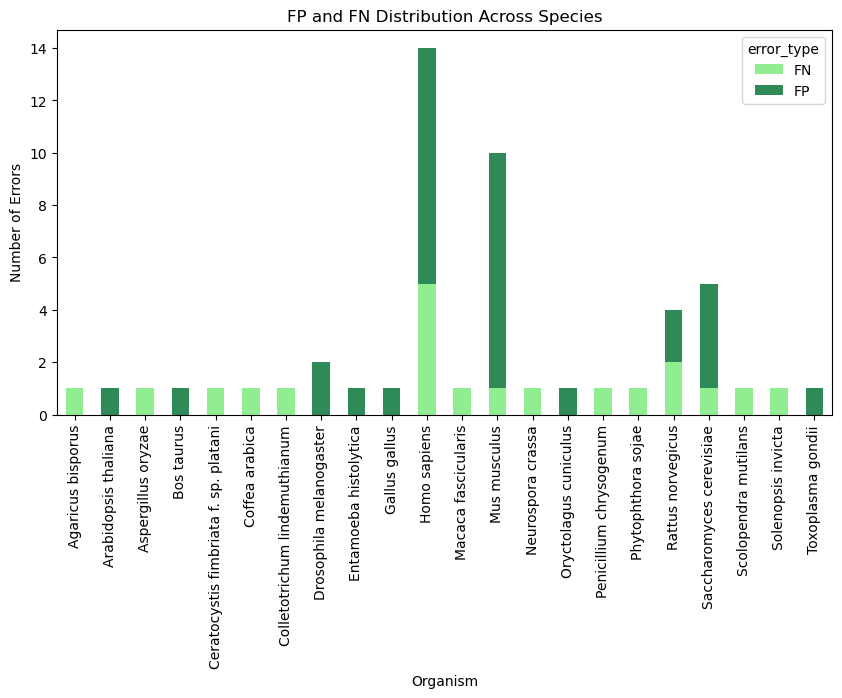

In [3]:
# Are the errors (both FP and FN) equally distributed among taxa/species?
species_map = dict(zip(info["UniprotAccession"], info["Organism"]))
bench_df["Organism"] = bench_df["seq_id"].map(species_map)
bench_df["pred"] = y_pred_all   # or y_pred_sel

bench_df = bench_df.dropna(subset=["Organism"])

#define TN/TP/ FN/FP
bench_df["error_type"] = "TP"
bench_df.loc[(bench_df["label"] == 1) & (bench_df["pred"] == 0), "error_type"] = "FN"
bench_df.loc[(bench_df["label"] == 0) & (bench_df["pred"] == 1), "error_type"] = "FP"
bench_df.loc[(bench_df["label"] == 0) & (bench_df["pred"] == 0), "error_type"] = "TN"
bench_df.loc[(bench_df["label"] == 1) & (bench_df["pred"] == 1), "error_type"] = "TP"

# counts the errors per species
error_counts = (
    bench_df[bench_df["error_type"].isin(["FP", "FN"])]
    .groupby(["Organism", "error_type"])
    .size()
    .unstack(fill_value=0)
)

# normalise by sample count
species_totals = bench_df.groupby("Organism").size()

# plot error counts accross species- barpot
colors=sns.color_palette("hls", 8)
error_counts.plot(kind="bar", stacked=True, figsize=(10,5), color=["lightgreen", "seagreen"])
plt.ylabel("Number of Errors")
plt.title("FP and FN Distribution Across Species")
plt.savefig("Species_dist_FP_FN.png")
plt.show()

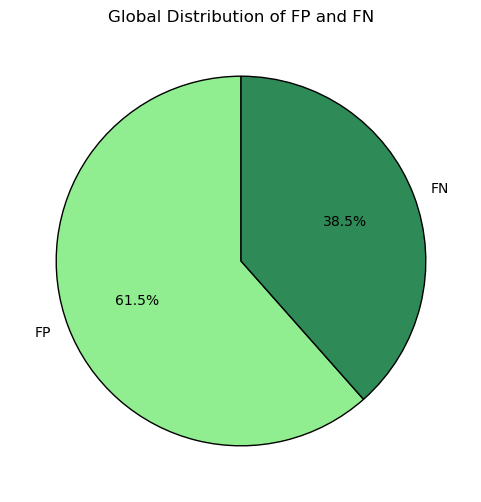

In [4]:
# pie chart of FN FP global distribution
# extract only FP and FN rows
errors_only = bench_df[bench_df["error_type"].isin(["FP", "FN"])]

# count FP and FN
counts = errors_only["error_type"].value_counts()
labels = counts.index
sizes = counts.values

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    colors=["lightgreen", "seagreen"],
    wedgeprops={'linewidth':1, 'edgecolor':'black'},
    startangle=90
    
)
plt.title("Global Distribution of FP and FN")
plt.savefig("GLobal_dis_FP_FN.png")
plt.show()

In [5]:
# FN/FP counts are taken form above (already calculated)

# include all species (those with 0 errors)
all_species = bench_df["Organism"].unique()
error_counts = error_counts.reindex(all_species, fill_value=0)

# filter species with enough samples
species_totals = bench_df.groupby("Organism").size()
valid_species = species_totals[species_totals >= 5].index
error_counts = error_counts.loc[valid_species]

# FP and FN series
fp_counts = error_counts["FP"]
fn_counts = error_counts["FN"]

# remove 0-error species for clean plots
# removing species with 0 false postives and 0 false negatives

fp_counts = fp_counts[fp_counts > 0]
fn_counts = fn_counts[fn_counts > 0]


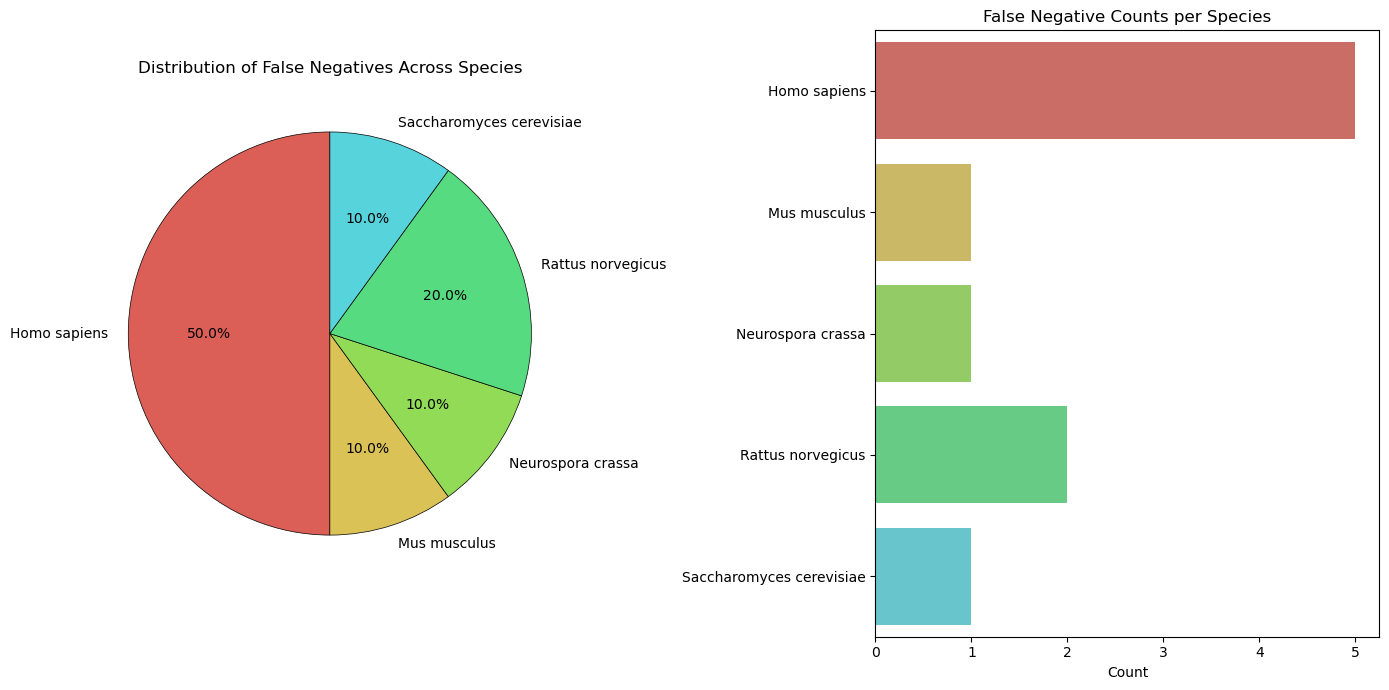

In [11]:
# setting colors to match organisms
palette = sns.color_palette("hls", 8)
fn_df = fn_counts.reset_index()
fn_df.columns = ["Organism", "FN"]
fn_df["color_key"] = fn_df["Organism"]
colors_fn = palette[:len(fn_counts)]
color_map = {org: col for org, col in zip(fn_df["Organism"], colors_fn)}

# FN distribution for pie chart
# ax[0]- left subplot
# ax[1]- right subplot
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].pie(
    fn_counts,
    labels=fn_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_fn,
    wedgeprops={'linewidth':0.5, 'edgecolor':'black'}
)
ax[0].set_title("Distribution of False Negatives Across Species")

# Barplot absolute counts
sns.barplot(
    data=fn_df,
    x="FN",
    y="Organism",
    hue="color_key",
    palette=color_map,
    dodge=False,
    legend=False
)

ax[1].set_title("False Negative Counts per Species")
ax[1].set_xlabel("Count")
ax[1].set_ylabel("")

plt.tight_layout()
plt.savefig("pie_bar_FN_species_dis.png")
plt.show()


/tmp/ipykernel_18494/415079692.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


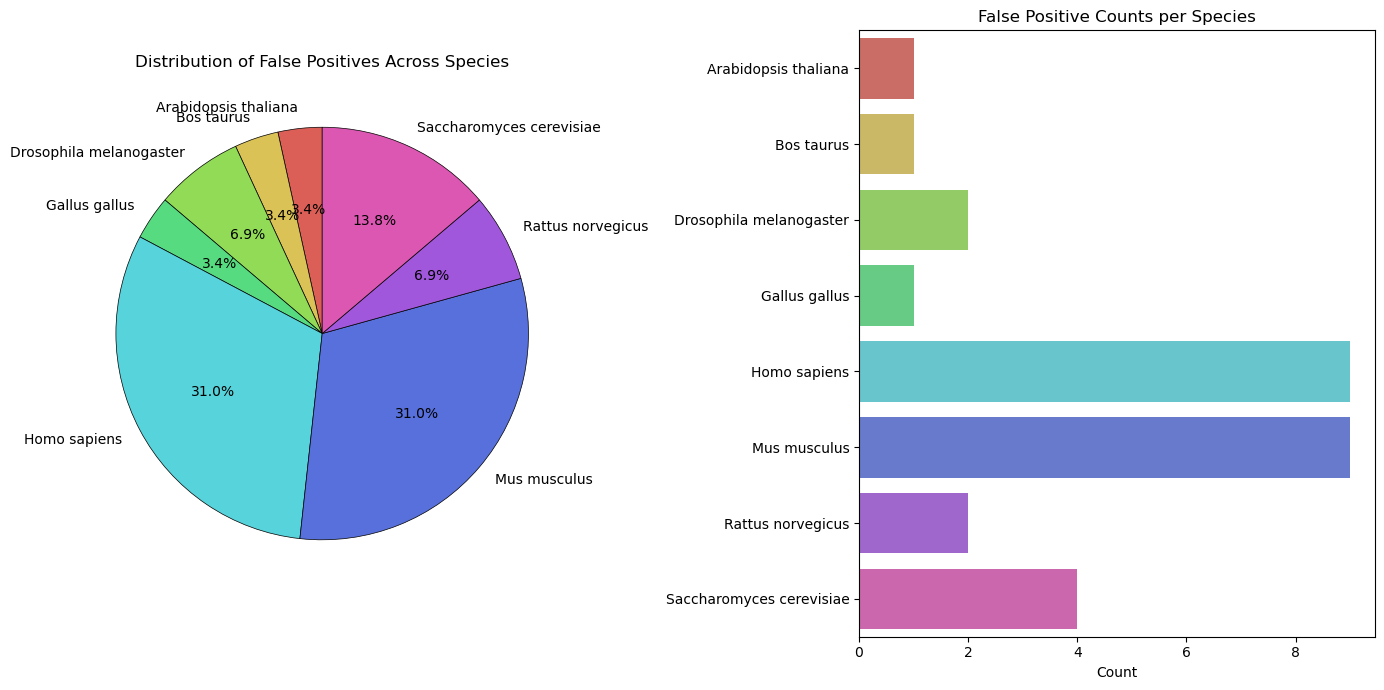

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
palette = sns.color_palette("hls", 8)
colors_fp = palette[:len(fp_counts)]

ax[0].pie(
    fp_counts,
    labels=fp_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_fp,
    wedgeprops={'linewidth':0.5, 'edgecolor':'black'}
)
ax[0].set_title("Distribution of False Positives Across Species")

# Barplot (FP absolute counts)
sns.barplot(
    x=fp_counts.values,
    y=fp_counts.index,
    ax=ax[1],
    palette=colors_fp
)
ax[1].set_title("False Positive Counts per Species")
ax[1].set_xlabel("Count")
ax[1].set_ylabel("")

plt.tight_layout()
plt.savefig("pie_bar_FP_species.png")
plt.show()


==== The fraction of TM positive FPs is : 0.65625 ==== 
 



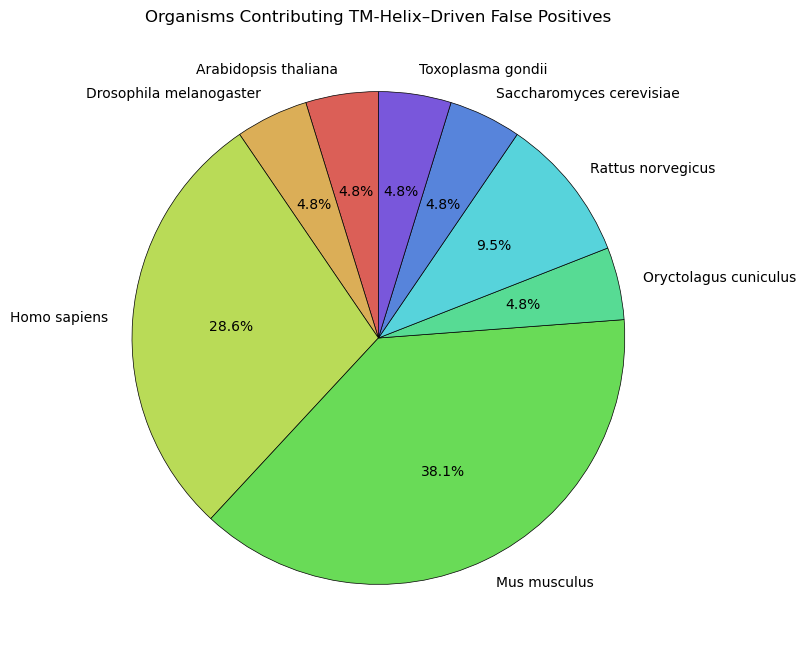

In [12]:
# FALSE POSITIVE ANALYSIS

# many false positives are due to the presence of the TM Helix (hydrophobic) at the protein N-terminus

# Isolate FP predictions in the benchmark dataset
# Using metadata extracted from UniProtKB, compute the fraction of FP predictions that have a transmembrane helix in the first 90 residues

TMHelix = dict(zip(info["UniprotAccession"], info["TMHelixFirst90"]))
# handling NaNs too
bench_df["TM"] = (
    bench_df["seq_id"]
    .map(TMHelix)        
    .fillna(0)           
    .astype(float)       
    .astype(int)         
    > 0                  
)

FP_only = bench_df[bench_df["error_type"] == "FP"]

# true = 1, false =0 (pandas takes booleans as integers)
# calculates the fraction of TMHelix>90 TRUE in the false positives
# HENCE almost 67% of False positives could be due of the presence of the TMHelix in the N terminus

fraction = FP_only["TM"].mean()
print(f"==== The fraction of TM positive FPs is : {fraction} ==== \n \n") # 0.65625

# this counts how many True values there are in TM columns for every organism
fp_tm_count = FP_only.groupby("Organism")["TM"].sum()
tm= fp_tm_count[fp_tm_count >= 1 ]

palette = sns.color_palette("hls", 10)
colors_fp_tm = palette[:len(tm)]
plt.figure(figsize= (8,8))
plt.pie(
    tm.values,
    labels=tm.index,
    autopct='%1.1f%%',
    startangle=90,
    colors= colors_fp_tm,
    wedgeprops={'linewidth':0.5, 'edgecolor':'black'}
)
plt.title("Organisms Contributing TM-Helix–Driven False Positives")
plt.savefig("TM_FP_Org.png")
plt.show()
# These organisms are the ones responsible for the 65% of false positives explained by N-terminal TM helices

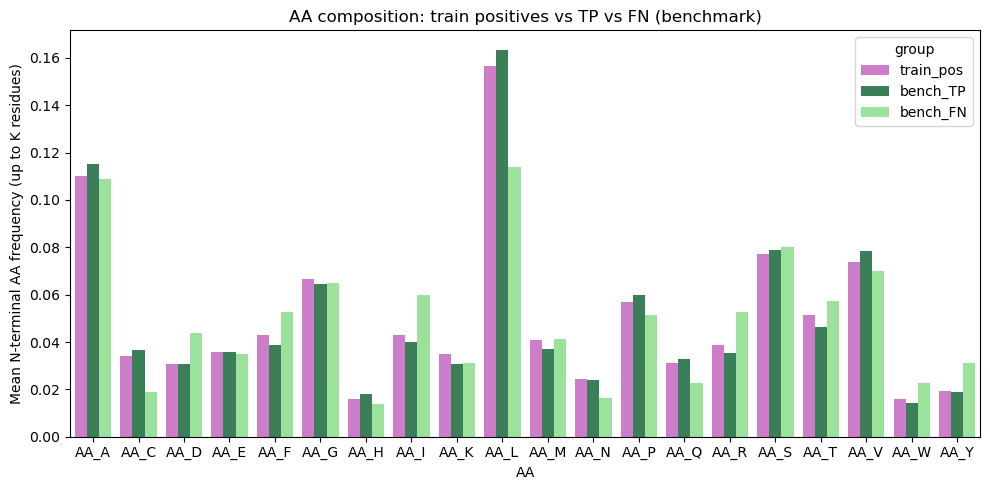

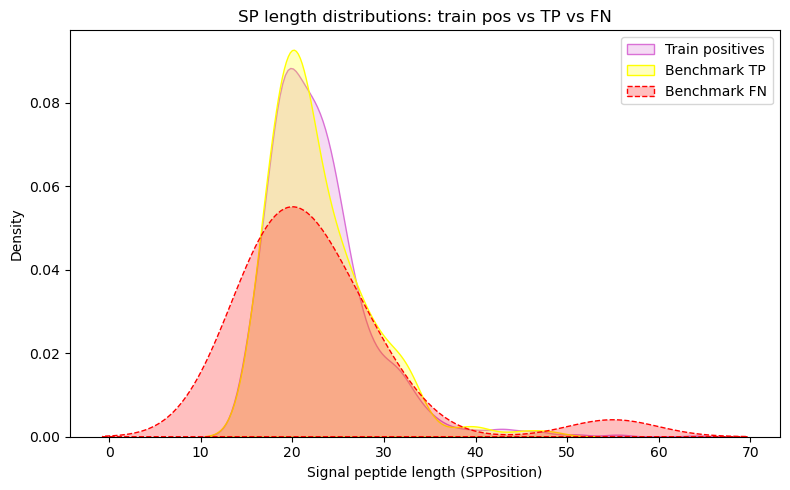

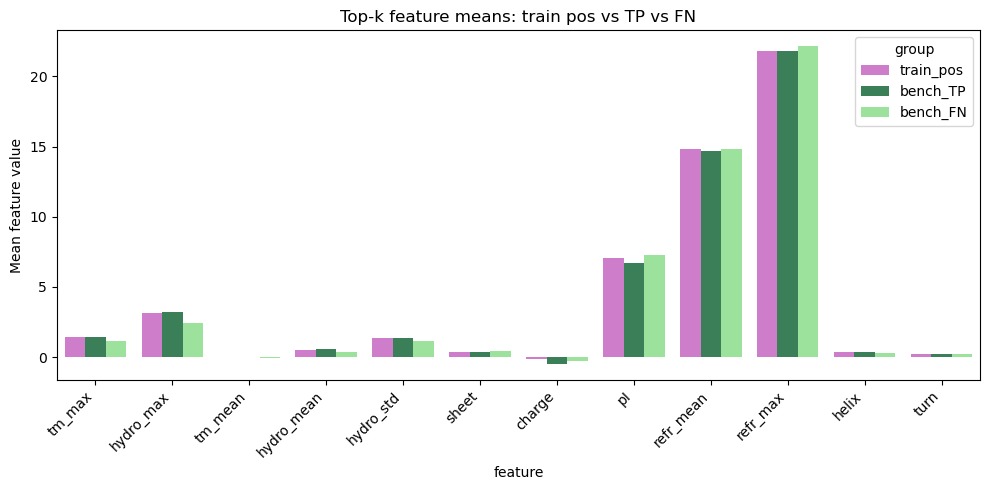

In [16]:
# False Negative analysis
# 1. FN may be due to a different composition of the N-terminal region (with the selected K) than expected
# Compare compositions of positive examples from training sets up to K residues, benchmarking true positives up to K and benchmarking false negatives up to K 

train_pos = df[df["label"] == 1]
bench_pos_TP = bench_df[(bench_df["label"] == 1) & (bench_df["error_type"] == "TP")]
bench_pos_FN = bench_df[(bench_df["label"] == 1) & (bench_df["error_type"] == "FN")]

aa_cols = []
for c in bench_df.columns:
    if c.startswith("AA_"):
        aa_cols.append(c)

groups = {
    "train_pos": train_pos,
    "bench_TP": bench_pos_TP,
    "bench_FN": bench_pos_FN,
}

comp_list = []
for name, sub in groups.items():
    mean_comp = sub[aa_cols].mean()
    tmp = mean_comp.reset_index()
    tmp.columns = ["AA", "freq"]
    tmp["group"] = name
    comp_list.append(tmp)

comp_df = pd.concat(comp_list, ignore_index=True)

colors= ["orchid", "seagreen", "lightgreen"]
plt.figure(figsize=(10,5))
sns.barplot(data=comp_df, x="AA", y="freq", hue="group", palette= colors)
plt.ylabel("Mean N-terminal AA frequency (up to K residues)")
plt.title("AA composition: train positives vs TP vs FN (benchmark)")
plt.tight_layout()
plt.savefig("bar_AAcomp_Train_TP_FN.png")
plt.show()

# 2. FN may be due to the presence of a longer/shorter SP than expected:

# Compare length distributions of positive training examples, benchmarking true positives and benchmarking false negatives.

# map seq_idwith SPPosition for benchmark
sp_pos_map = dict(zip(info["UniprotAccession"], info["SPPosition"]))
bench_df["SPPosition"] = bench_df["seq_id"].map(sp_pos_map)
#benchmark
tp_len = bench_pos_TP["SPPosition"].dropna()
fn_len = bench_pos_FN["SPPosition"].dropna()

#train ositive length
train_pos_ids = train_pos["seq_id"] if "seq_id" in train_pos.columns else info.loc[
    (info["Set"] == "train") & (info["label"] == "positive"), "UniprotAccession"
]
train_pos_len = info.loc[info["UniprotAccession"].isin(train_pos_ids), "SPPosition"]

plt.figure(figsize=(8,5))
sns.kdeplot(train_pos_len, label="Train positives", fill=True, color= "orchid")
sns.kdeplot(tp_len, label="Benchmark TP", fill=True, color= "yellow")
sns.kdeplot(fn_len, label="Benchmark FN", fill=True, linestyle="--", color= "red")

plt.xlabel("Signal peptide length (SPPosition)")
plt.title("SP length distributions: train pos vs TP vs FN")
plt.legend()
plt.tight_layout()
plt.savefig("SP_len_train_TP_FN.png")
plt.show()


# 3. Are other features different? 
# Compare distributions of all features adopted.
feat_cols = [f for f in best_subset if not f.startswith("AA_")]

groups2 = {
    "train_pos": train_pos,
    "bench_TP": bench_pos_TP,
    "bench_FN": bench_pos_FN,
}

feat_list = []
for name, sub in groups2.items():
    mean_feat = sub[feat_cols].mean()
    tmp = mean_feat.reset_index()
    tmp.columns = ["feature", "value"]
    tmp["group"] = name
    feat_list.append(tmp)

feat_df = pd.concat(feat_list, ignore_index=True)

plt.figure(figsize=(10,5))
sns.barplot(data=feat_df, x="feature", y="value", hue="group", palette= colors)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean feature value")
plt.title("Top-k feature means: train pos vs TP vs FN")
plt.tight_layout()
plt.savefig("top_k_feature_train_TP_FN.png")
plt.show()
